# Methoden en Technieken -- Blok 1b

## Datapunt Opdracht
In deze opdracht worden de volgende leeruitkomsten getoetst, relevante termen zijn **dik** gedrukt:
- A2: Je stelt voor een AI-oplossing juridische, ethische, organisatorische, **functionele en
technische requirements** op.
- B1: Je **verkent en prepareert een dataset voor het trainen en testen van een AI-model** en
kan de voor- en nadelen van het gebruik van een bestaande dataset onderbouwen, rekening
houdend met technische en ethische randvoorwaarden.
- B2: Je **stelt op basis van requirements en data een geschikte architectuur voor een AI-
oplossing op en selecteert daarvoor passende AI-technieken gebruik makend van bijvoorbeeld
machine learning, deep learning**, kennisrepresentatie, computer vision en natural language
processing.
- B3: Je **ontwikkelt een nieuw** of voorgetraind **AI-model** volgens een iteratief en systematisch
proces.
- C2: **Je evalueert en beoordeelt de kwaliteit van een AI-model aan de hand van kwaliteitscriteria die in het vakgebied erkend worden** zoals robustness, **performance**, scalability,
**explainability**, **model complexity** en resource demand.

Dit is een individuele opdracht. Het is toegestaan met elkaar de opdracht te bespreken, maar iedereen schrijft zijn eigen code en antwoorden. Mocht je code van het internet hebben overgenomen/aangepast, vermeld dan de bron in het commentaar. Het gebruik van generatieve AI (Chat-GPT, etc...) is *alleen* toegestaan bij de voorbereiding op de opdracht. Denk hierbj aan activiteiten zoals brainstormen, of het maken van een plan. Het is niet toegestaan code of tekst van generative AI over te nemen. (Level 2 van de AI Assessment Scale)


In [10]:
import os
import torch

os.environ["KERAS_BACKEND"] = "torch"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

import keras
import numpy as np
import matplotlib.pyplot as plt


## Data

In deze opdracht werken we met gesimuleerde data, deze wordt hier aangemaakt. We gaan hier wel van uit dat dit de volledige data is, het is niet toegestaan extra trekkingen te doen.

In [11]:
# Verband tussen x en y
def f(x):
    return (+ 1.5*np.tanh(20*x - 6)  
            - 2.0*np.tanh(10*x - 4)
            + 1.5*np.tanh( 8*x - 4)
            - 1.0*np.tanh(15*x - 12))


In [12]:
# Trek data
np.random.seed(42)# Random state 2 zorgt voor een bijna perfecte fit door puur geluk
xdat = np.random.uniform(0,1, size=1000).reshape(-1,1)
ydat = f(xdat) + np.random.normal(scale = 0.2, size = 1000).reshape(-1,1)

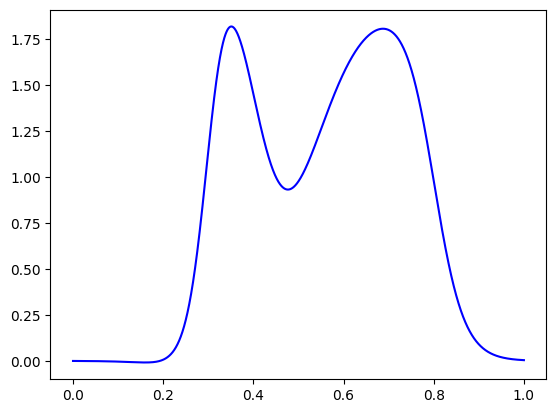

In [13]:
# Plot echt verband
xplot = np.linspace(0,1,10001)
yplot = f(xplot)
plt.plot(xplot, yplot, 'b-')
plt.show()

In deze opdracht is het de bedoeling om middels een neuraal netwerk de data $(xdat,ydat)$ die hierboven werdt gegeven te benaderen. Het uiteindelijke model behoort,
* de data / de functie $f$ zo goed mogelijk te benaderen, en
* zo simpel mogelijk te zijn (interpreteerbaarheid van model).

Tip: Lees eerst alle deelvragen goed door voordat je begint met beantwoorden.

## Deel 1

Bestudeer de definitie van $f$ en de grafiek van deze functie.

Hoe zou een zo simpel mogelijk neuraal netwerk voor dit probleem er uit zou zien. Bijvoorbeeld: hoeveel nodes/neuronen zou het moeten hebben? Hoeveel gewichten? Welke activatiefunctie(s)? Wees zo specifiek mogelijk.

> Jouw antwoord hier

### Keuze van het aantal lagen

Op pagina 158 van het boek [*Introduction to Neural Networks for Java, Second Edition*](https://d1wqtxts1xzle7.cloudfront.net/62266271/Deep_Learning20200303-80130-1s42zvt.pdf?1738394282=&response-content-disposition=inline%3B+filename%3DDeep_Learning.pdf&Expires=1760352999&Signature=ASZMxP-rd7tkPYZ9zDstgcVsdpSJybNhQcBjTzaV5kdlxv~HUvC8Fe3ilLqhzMWbGSfXdTGE4Zagv2rkIXhIDGjam2uBCIx-sLfwcSuoXCGPWTo3bnslV7nQEv6MK6DaVxOVB7iQGweIHW9A8FMmoE8ZQoJ0ibs6EZ9ufJEpPm8m-NC8roGD~t5wWvNTbcfa79Uyt-bMsBPcUv60V8~gRmcVdQAY-ArCHkddeaCtHglQwT3GEr7TTjG5NYcJ5ccT7krKQVyI56neM6jf~bsUl4eRafDl3jwApErVOqTieB53nefClaAcAp1t0rjWy0yk~fzl5VvHmpDl08sPHbhXuw__&Key-Pair-Id=APKAJLOHF5GGSLRBV4ZA)  
wordt beschreven dat een neuraal netwerk met één verborgen laag in staat is om elke continue functie te benaderen wat ook klopt volgens de universal approximation thereum.

Een vergelijkbare uitleg wordt gegeven in [*Deep Learning*](https://d1wqtxts1xzle7.cloudfront.net/62266271/Deep_Learning20200303-80130-1s42zvt.pdf?1738394282=&response-content-disposition=inline%3B+filename%3DDeep_Learning.pdf&Expires=1760352999&Signature=ASZMxP-rd7tkPYZ9zDstgcVsdpSJybNhQcBjTzaV5kdlxv~HUvC8Fe3ilLqhzMWbGSfXdTGE4Zagv2rkIXhIDGjam2uBCIx-sLfwcSuoXCGPWTo3bnslV7nQEv6MK6DaVxOVB7iQGweIHW9A8FMmoE8ZQoJ0ibs6EZ9ufJEpPm8m-NC8roGD~t5wWvNTbcfa79Uyt-bMsBPcUv60V8~gRmcVdQAY-ArCHkddeaCtHglQwT3GEr7TTjG5NYcJ5ccT7krKQVyI56neM6jf~bsUl4eRafDl3jwApErVOqTieB53nefClaAcAp1t0rjWy0yk~fzl5VvHmpDl08sPHbhXuw__&Key-Pair-Id=APKAJLOHF5GGSLRBV4ZA)  
van Goodfellow, Bengio en Courville (p. 205, sectie 6.6 *Universal Approximation Properties and Depth*). Daarin wordt benadrukt dat één verborgen laag voldoende is om een brede klasse van continue functies te benaderen, mits er gebruik wordt gemaakt van een “squashing” activatiefunctie zoals sigmoid of tanh.

### Keuze van het aantal neuronen

Voor de bepaling van het aantal neuronen in de verborgen laag is gekeken naar hoe neuronen bijdragen aan de vorm van de te benaderen functie.  
In [*Neural Networks and Deep Learning*](http://neuralnetworksanddeeplearning.com/chap4.html#five_bumps) wordt uitgelegd dat elk extra neuron een extra “bump” (lokale kromming) in de functie mogelijk maakt. Daar wordt concreet getoond dat een netwerk met vijf neuronen de functie tot vijf keer op en neer kan laten gaan.  

Wiskundig kan dit principe worden uitgedrukt als $2n + 1$, waarbij $n$ het aantal neuronen in de verborgen laag is.  
Aangezien de doel­functie in dit geval drie stijgingen en twee dalingen vertoont, zijn minimaal vier neuronen nodig om deze correct te kunnen modelleren.  
Een netwerk met drie neuronen zou onvoldoende capaciteit hebben om deze variaties te reproduceren. Eén verborgen laag is hiervoor voldoende. En het gebruik van een squashing function zoals sigmoid of tanh wordt nog een keer aangehaald.

### Keuze van de activatiefunctie

Zoals beschreven in [*A Survey on Activation Functions and their Relation with Xavier and He Normal Initialization*](https://arxiv.org/pdf/2004.06632)  
(sectie 2.3.2, p. 8) is de **tanh-functie** een uitbreiding op de sigmoid-functie.  
Het belangrijkste voordeel van tanh is dat de output rond nul gecentreerd is, wat de backpropagation vergemakkelijkt en voorkomt dat de activatie te snel verzadigt.  

In de conclusie van dezelfde publicatie (p. 15) wordt bovendien vermeld dat de tanh-functie vaak de voorkeur heeft bij relatief ondiepe netwerken.  
Gecombineerd met de eerdere overwegingen (één verborgen laag met een squashing-activatie) is tanh daarom een logische en goed onderbouwde keuze voor dit model.

### Keuze van de weight-initialisatie

Wanneer de gewichten allemaal met dezelfde waarde (zoals 0 of 1) worden geïnitialiseerd, leren de neuronen identieke patronen — dit staat bekend als het *symmetry problem*  
(zie [*Why Initialize a Neural Network with Random Weights?*](https://machinelearningmastery.com/why-initialize-a-neural-network-with-random-weights/), sectie *Why Not Set Weights to Zero?*).  
Daarom moeten de gewichten willekeurige startwaarden krijgen.

De waarden mogen echter niet te groot of te klein zijn.  
Zoals uitgelegd in [*Understanding and Study of Weight Initialization in Artificial Neural Networks with Back Propagation Algorithm*](http://it-in-industry.org/index.php/itii/article/view/290/253) (p. 5, net boven sectie 4 *Results*),  
kunnen te kleine waarden leiden tot het verdwijnen van signalen (*vanishing gradients*), terwijl te grote waarden juist explosieve gradiënten veroorzaken (*exploding gradients*).

In de abstract van [*Understanding the Difficulty of Training Deep Feedforward Neural Networks*](http://proceedings.mlr.press/v9/glorot10a/glorot10a.pdf)  
wordt beschreven dat willekeurige initialisatie bij diepe netwerken vaak ongeschikt is omdat activaties daardoor te sterk krimpen of groeien — vooral bij activatiefuncties zoals tanh.  

Daarom wordt in de literatuur vaak de **Xavier-initialisatie** aanbevolen.  
Deze methode is specifiek ontworpen voor activatiefuncties zoals sigmoid en tanh, en zorgt ervoor dat de variantie van activaties en gradiënten in balans blijft.  
Dit wordt ook helder uitgelegd in [*Xavier Initialization – GeeksforGeeks*](https://www.geeksforgeeks.org/deep-learning/xavier-initialization/), onder de sectie *Understanding Xavier Initialization*.

### Samengevat

Op basis van bovenstaande overwegingen is gekozen voor een **neuraal netwerk met één verborgen laag** en **vier neuronen**.  
De activatiefunctie in deze laag is **tanh**, omdat deze goed aansluit bij ondiepe netwerken en helpt om stabiele gradiënten te behouden.  
De gewichten worden geïnitialiseerd met **Xavier-initialisatie**, zodat de variatie van activaties en gradiënten in balans blijft en het leerproces efficiënt verloopt.  
Deze keuzes zorgen samen voor een model dat stabiel, efficiënt en wiskundig goed onderbouwd is voor de gegeven regressietaak.


- Geen normalisation doen, want dat maakt het minder explainable omdat je het dan terug moet rekeenen naar de originele waardes.
- je mag bias uit zetten bij de laatste als je kan uitleggen waarom, de functies zelf hebben ook geen bias

## Deel 2

Voer hier eventuele datapreparatie uit die nodig is voordat je een model gaat trainen. Licht gemaakte keuzes kort en bondig toe.

## Data prep keuzes

**Train/Validatie Split (80/20):**
- Gebruikt `train_test_split` met `random_state=42` voor reproduceerbare resultaten
- 800 trainingssamples, 200 validatiesamples standaard split van 80/20
- Shuffle=True voor goede verdeling over het domein aangezien de data syntetisch is

**Geen Normalisatie:**
- **X-data**: is al tussen de 0 en 1 dus schalen is niet nodig
- **Y-data**: behouden in originele schaal [-0.5, 2.3] zodat het na het trainen explainable blijft
- Model gewichten blijven interpreteerbaar t.o.v. originele functie f(x)
- Met juiste weight initialisatie (Xavier) kan het netwerk deze schaal gebruiken

In [14]:
from sklearn.model_selection import train_test_split

# Split the data into train and validation sets (80/20 split)
X_train, X_val, y_train, y_val = train_test_split(
    xdat, ydat, 
    test_size=0.2, 
    random_state=42,
    shuffle=True      # Ensure random distribution
)

## Deel 3

Fit een zo simpel mogelijk model. Je zult hiervoor meerdere iteraties doorlopen, leg bij iedere iteratie uit
- welke keuzes je hebt gemaakt, en waarom?
- wat je opvalt aan het model en hoe je dit in een volgende iteratie aan gaat pakken.

Wees kort en bondig.

(Als je een 'dood spoor' in gaat, mag je deze iteraties wissen... we willen het proces zien hoe je bij je uiteindelijk model komt.)

In [ ]:
model_v1 = keras.Sequential([
    keras.layers.Dense(4, 
                      activation='tanh', 
                      kernel_initializer='glorot_uniform',  # Xavier initialisatie
                      input_shape=(1,)),
    keras.layers.Dense(1, 
                      use_bias=False,  # Geen bias in output laag
                      kernel_initializer='glorot_uniform')
])

# Compile model met Adam optimizer en MSE loss
model_v1.compile(keras.optimizers.Adam(learning_rate=0.2), 
                loss='mean_squared_error',
                metrics=['mae'])

# Early stopping callback
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',      # Monitor validation loss
    patience=25,             # Stop after 10 epochs without improvement
    restore_best_weights=True # Restore weights from best epoch
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',     # what to watch
    factor=0.1,             # multiply LR by this factor
    patience=10,            # how many epochs of no improvement
    threshold=0.0001,
    min_lr=0,
    verbose=1
)

# early_stopping = keras.callbacks.EarlyStopping(
#     monitor='val_loss',       # Monitor validation loss
#     patience=250,             # Stop after 10 epochs without improvement
#     restore_best_weights=True # Restore weights from best epoch
# )

# reduce_lr = keras.callbacks.ReduceLROnPlateau(
#     monitor='val_loss',     # what to watch
#     factor=0.2,             # multiply LR by this factor
#     patience=100,           # how many epochs of no improvement
#     threshold=0.00005,
#     min_lr=0,
#     verbose=1
# )

# Train het model
history_v1 = model_v1.fit(X_train, y_train, 
                         validation_data=(X_val, y_val),
                         epochs=1000,              # More epochs
                         batch_size=32,
                         verbose=1,               # Progress bar per epoch
                         callbacks=[early_stopping, reduce_lr])

# Bewaar dit model als final_model voor de plot in deel 4
final_model = model_v1

print(f"\nModel samenvatting:")
model_v1.summary()

Epoch 1/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.5674 - mae: 0.6419 - val_loss: 0.4903 - val_mae: 0.6047 - learning_rate: 0.2000
Epoch 2/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.5410 - mae: 0.6295 - val_loss: 0.4387 - val_mae: 0.5448 - learning_rate: 0.2000
Epoch 3/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.5036 - mae: 0.5840 - val_loss: 0.3690 - val_mae: 0.5098 - learning_rate: 0.2000
Epoch 4/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.4103 - mae: 0.5351 - val_loss: 0.3086 - val_mae: 0.4730 - learning_rate: 0.2000
Epoch 5/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.3323 - mae: 0.4738 - val_loss: 0.2781 - val_mae: 0.4252 - learning_rate: 0.2000
Epoch 6/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2649 - mae: 0.4208 - val_loss: 0.2000 - val_mae: 0.3796 - learning_rate: 0.2000
Epoch 7/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1933 - mae: 0.3653 - val_loss: 0.1953 - val_mae: 0.3491 - learning_rate: 0.2000
Epoch

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 4)              │             8 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38 (152.00 B)

 Trainable params: 12 (48.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 26 (104.00 B)

> Jouw antwoord hier

### Iteratie 1 - Model architectuur zoals beschreven in deel 1

**Architectuur:**
- 1 verborgen laag met 4 neuronen
- tanh activatie functie
- Xavier weight initialisatie
- Geen bias in output laag want de data is ook zonder bias gegenereerd

- Voor de optimizer wil ik eerst Adam proberen, volgens [An overview of gradient descent optimization
algorithms](https://arxiv.org/pdf/1609.04747) op pagina 8 net boven de heading van 4.7 AdaMax wordt beschreven hoe Adam een goede basis is omdat het een veel gevallen beter werkt dan adaptive learning-methods zonder veel hyper parameter tweaking. 
- Voor de learnign loss kies ik MSE wat vaak gebruikt wordt voor regressie zodat het grotere fouten zwaarder mee rekent dan kleinere.
- Als performance metric gebruik ik MAE omdat het makkelijk interpreteerbaar is wat een van de eisen was voor deze opdracht.
- Voor de batch size begin ik met 32 wat een standaard waarde.
- De epochs zet ik voor de eerste versie op 100 om mee te beginnen om een idee te krijgen van hoeveel er nodig is met trainen.
- De learning rate heb ik op de 0.001 standaard gelaten wat een goede middle middle ground is voor veel problemen en daarom de default value is.

### Iteratie 2 extra training

**Wijzigingen**
Ik zie dat 100 epochs veels te weinig is en het trainen enorm snel gaat daarom zet ik de epochs nu op 1000 met early stoppping op basis van de `val_loss` en `restore_best_weights=True` om te zorgen dat er genoeg getrained wordt maar ook optijd gestopt.

**Resultaat**

5/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1550 - mae: 0.3150 - val_loss: 0.1523 - val_mae: 0.3076

Het resultaat is nu dat het model op ongeveer 500 epochs niks nieuws meer leert. Het blijft nog even een klein beetje op en neer springen en dan stopt het door de early stopping. De fout is nogsteeds hoog en de loss ook. Het lijkt er op dat het model in een lokaal minimum beland is waardoor het niet lukt verder te trainen en het overfit ook niet omdat het model niet complex genoeg is om de functie goed te fitten. 

### Iteratie 3

**Wijzigingen**

Omdat het leren vast lijkt te lopen met de standaard learning rate van 0.001 heb ik een oplossing nodig om het lokale minimum uit te komen. De eerste oplossing die ik ga proberen is het tweaken van de learning rate. Omdat dit het model even simpel houd en makkelijker uit te leggen houd als er veranderingen zijn. Ik ga de learning rate hoger maken zodat er meer exploration mogelijk is en meer kans om uit lokale minima te komen.

**Resultaat**

`learning rate 0.1`
Epoch 166/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0544 - mae: 0.1853 - val_loss: 0.0385 - val_mae: 0.1521

`learning rate 0.2`
Epoch 155/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0555 - mae: 0.1877 - val_loss: 0.0399 - val_mae: 0.1533

Ik heb de waardes 0.01, 0.001 en 0.1 geprobeert bij de eerste 2 pogingen was er niet veel verandering te zien ten opzichte van de default learning rate. Pas bij de learning rate van 0.1 en 0.2 wat hoge waardes zijn lukt het het model omd uit het lokale minimum te komen en meer te leren.

### Iteratie 4

**Wijzigingen**

Aangezien er nog een klein beetje loss is tijdens het trainen en de val_mae nogsteeds 1.5 is wil ik proberen om met een callback de learning rate te reducen waneer er een plateu is zodat er op latere momenten in het trainen een kleinere learning rate is om te kijken of ik nog wat meer van de loss af kan halen. Ik zet de waardes om te beginnen op de fault wat een goede basis is en om dan te kijken wat er gebeurd.

**Resultaat**

Epoch 138/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0407 - mae: 0.1610 - val_loss: 0.0353 - val_mae: 0.1430 - learning_rate: 0.0020


## Deel 4

Onderstaande code plot de voorspellingskromme van jouw model $\hat{f}$, in het ideale geval ziet je resultaat er uit zoals hieronder, of beter, met blauwe en gestippelde lijnen vrijwel boven elkaar.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


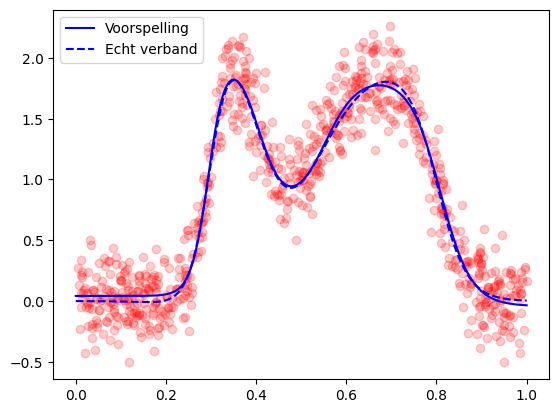

In [16]:
xpred = xplot
ypred = final_model.predict(xpred)

plt.plot(X_train, y_train, 'ro', alpha=0.2)
plt.plot(xpred, ypred, 'b-', label = 'Voorspelling')
plt.plot(xplot, yplot, 'b--', label = 'Echt verband')
plt.legend()
plt.show()

Voer deze code uit, wat valt je op? Zou je zeggen dat je de oorspronkelijke $f$ achterhaald hebt?

> Jouw antwoord hier

## Deel 5

Bestudeer de gewichten van je model, zou je zeggen dat je de oorspronkelijke $f$ achterhaald hebt?

In [17]:
# Gebruik deze cel voor je code, voeg gerust cellen toe

> Jouw antwoord hier

## Deel 6

Evalueer je model met een geschikte kwaliteitsmaat. Wat valt je op?

In [18]:
# Gebruik deze cel voor je code, voeg gerust cellen toe

> Jouw antwoord hier